In [1]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

## Load Data

In [2]:
# 1x3: CW, High Pref, Mid Pref, Low Pref
df_1x3 = pd.read_csv("../data/processed/daily/daily_1969_2024_cw_quantile_returns_1x3.csv",
                     index_col="date", parse_dates=True)

# 3x3: CW + 9 EBC x Pref portfolios
df_3x3 = pd.read_csv("../data/processed/daily/daily_1969_2024_cw_quantile_returns_3x3.csv",
                     index_col="date", parse_dates=True)

print("1x3 columns:", df_1x3.columns.tolist())
print("3x3 columns:", df_3x3.columns.tolist())

1x3 columns: ['CW', 'High Pref', 'Mid Pref', 'Low Pref']
3x3 columns: ['CW', 'EBC_High_Pref_High', 'EBC_High_Pref_Mid', 'EBC_High_Pref_Low', 'EBC_Mid_Pref_High', 'EBC_Mid_Pref_Mid', 'EBC_Mid_Pref_Low', 'EBC_Low_Pref_High', 'EBC_Low_Pref_Mid', 'EBC_Low_Pref_Low']


## GMV Optimizer & Backtest Engine

In [3]:
def gmv_weights(Sigma, ridge=1e-8, long_only=True):
    """Global Minimum Variance weights. Long-only by default."""
    n = Sigma.shape[0]
    Sigma = 0.5 * (Sigma + Sigma.T) + ridge * np.eye(n)

    def obj(w):
        return w @ Sigma @ w

    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds = [(0, 1)] * n if long_only else [(None, None)] * n

    res = minimize(obj, np.ones(n) / n, method='SLSQP',
                   bounds=bounds, constraints=constraints)
    if not res.success:
        raise ValueError(res.message)
    return res.x


def run_gmv_backtest(df, rebalance_freq=63, lookback=756, use_full_history=False, min_obs=504):
    """
    Rolling GMV backtest on daily data.

    Parameters
    ----------
    df             : DataFrame of daily returns (columns = assets)
    rebalance_freq : trading days between rebalances (63 ≈ 3 months)
    lookback       : trading days of history for covariance (756 ≈ 3 years)
    use_full_history: expanding window if True
    min_obs        : minimum trading days before first allocation (504 ≈ 2 years)
    """
    df = df.dropna()
    cols = df.columns.tolist()

    wts = pd.DataFrame(np.nan, index=df.index, columns=cols, dtype=float)
    ret = pd.Series(np.nan, index=df.index, dtype=float)

    t = min_obs
    while t < len(df):
        train = df.iloc[:t] if use_full_history else df.iloc[max(0, t - lookback):t]

        Sigma = train.cov().values
        if not np.isfinite(Sigma).all():
            t += 1
            continue

        w = gmv_weights(Sigma)

        t_end = min(t + rebalance_freq, len(df))
        block = df.iloc[t:t_end]
        wts.iloc[t:t_end] = w
        ret.iloc[t:t_end] = block.values @ w

        t = t_end

    ret = ret.dropna()
    wts = wts.loc[ret.index]
    return ret, wts


def summary_stats(ret, freq=252):
    """Annualized stats for a daily return series."""
    ann_ret = (1 + ret.mean()) ** freq - 1
    ann_vol = ret.std() * np.sqrt(freq)
    sharpe  = ann_ret / ann_vol
    cum     = (1 + ret).prod() - 1
    logcum  = np.log1p(ret).cumsum()
    max_dd  = (logcum - logcum.cummax()).min()
    return pd.Series({
        'Ann. Return':  ann_ret,
        'Ann. Vol':     ann_vol,
        'Sharpe':       sharpe,
        'Cum. Return':  cum,
        'Max DD (log)': max_dd
    })


def plot_2asset_gmv(ret, wts, asset_a, asset_b, label_a, label_b, title_suffix):
    """Standard 3-panel plot for a 2-asset GMV backtest."""
    idx = ret.index
    fig, axes = plt.subplots(3, 1, figsize=(13, 12))

    # cumulative log-wealth
    ax = axes[0]
    for s, lbl in [(asset_a.loc[idx], label_a),
                   (asset_b.loc[idx], label_b),
                   (ret, ret.name)]:
        ax.plot(np.log1p(s).cumsum(), label=lbl)
    ax.set_title(f"Cumulative Log-Wealth – {title_suffix}")
    ax.set_ylabel("Log Wealth"); ax.legend(); ax.grid(True)

    # weight allocation
    ax = axes[1]
    ax.stackplot(wts.index, wts[label_a], wts[label_b], labels=[label_a, label_b])
    ax.set_title(f"GMV Weight Allocation – {title_suffix}")
    ax.set_ylabel("Weight"); ax.legend(loc="upper left"); ax.grid(True)

    # rolling 252-day correlation
    ax = axes[2]
    roll_corr = asset_a.rolling(252).corr(asset_b)
    ax.plot(roll_corr)
    ax.axhline(0, linestyle="--", color="gray")
    ax.set_title(f"Rolling 252-Day Correlation: {label_a} vs {label_b}")
    ax.set_ylabel("Correlation"); ax.grid(True)

    plt.tight_layout()
    plt.show()

## Backtest Settings

In [4]:
REBAL     = 63    # rebalance every ~3 months (63 trading days)
LOOKBACK  = 756   # ~3-year rolling covariance window (756 trading days)
FULL_HIST = False # True = expanding window; False = rolling LOOKBACK
MIN_OBS   = 504   # minimum ~2 years before first rebalance (504 trading days)

---
## Case 1: CW + Low Pref

In [5]:
assets_c1 = df_1x3[["CW", "Low Pref"]].dropna()

ret_c1, wts_c1 = run_gmv_backtest(
    assets_c1, rebalance_freq=REBAL, lookback=LOOKBACK,
    use_full_history=FULL_HIST, min_obs=MIN_OBS
)
ret_c1.name = "GMV(CW+LowPref)"

print(f"Backtest: {ret_c1.index.min().date()} to {ret_c1.index.max().date()}  ({len(ret_c1)} days)")
wts_c1.tail()

Backtest: 1971-12-28 to 2024-12-31  (13368 days)


,CW,Low Pref
date,,
2024-12-24,0.5,0.5
2024-12-26,0.5,0.5
2024-12-27,0.5,0.5
2024-12-30,0.5,0.5
2024-12-31,0.5,0.5


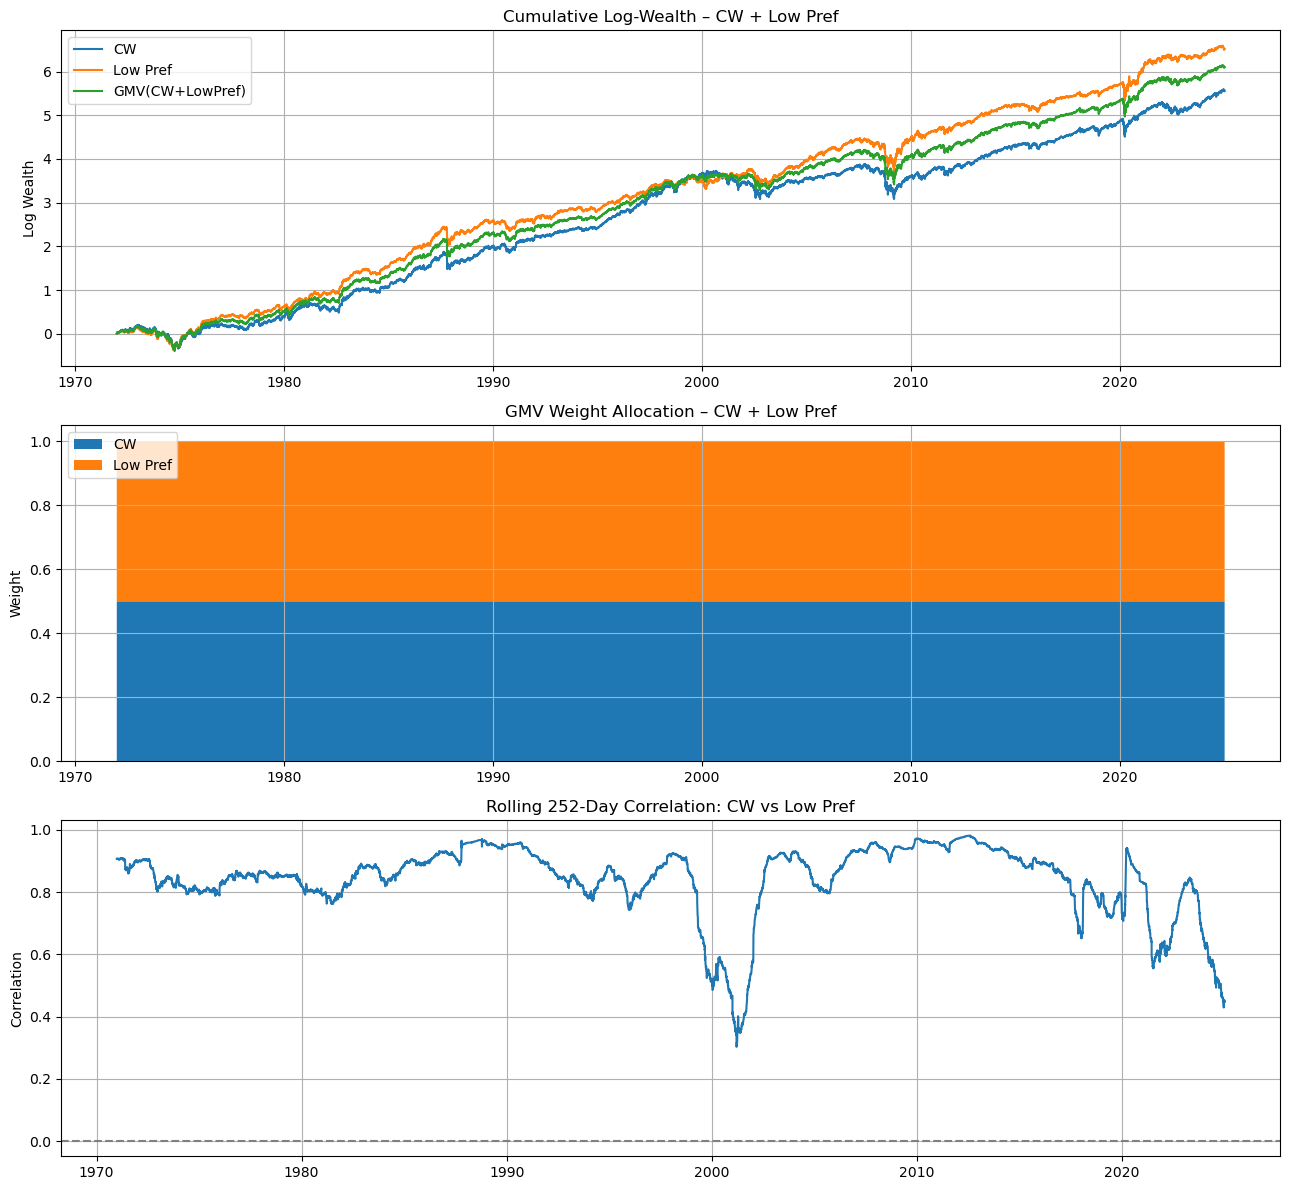

In [6]:
plot_2asset_gmv(
    ret_c1, wts_c1,
    assets_c1["CW"], assets_c1["Low Pref"],
    "CW", "Low Pref",
    "CW + Low Pref"
)

In [7]:
idx = ret_c1.index
pd.DataFrame({
    'CW':        summary_stats(assets_c1.loc[idx, 'CW']),
    'Low Pref':  summary_stats(assets_c1.loc[idx, 'Low Pref']),
    ret_c1.name: summary_stats(ret_c1),
}).T.round(4)

,Ann. Return,Ann. Vol,Sharpe,Cum. Return,Max DD (log)
CW,0.1270,0.1723,0.7374,256.9826,-0.7928
Low Pref,0.1460,0.1643,0.8890,672.4074,-0.8078
GMV(CW+LowPref),0.1365,0.1610,0.8475,442.9735,-0.7927


---
## Case 2: CW + High EBC & Low Pref

In [8]:
assets_c2 = df_3x3[["CW", "EBC_High_Pref_Low"]].dropna()

ret_c2, wts_c2 = run_gmv_backtest(
    assets_c2, rebalance_freq=REBAL, lookback=LOOKBACK,
    use_full_history=FULL_HIST, min_obs=MIN_OBS
)
ret_c2.name = "GMV(CW+HighEBC_LowPref)"

print(f"Backtest: {ret_c2.index.min().date()} to {ret_c2.index.max().date()}  ({len(ret_c2)} days)")
wts_c2.tail()

Backtest: 1971-12-28 to 2024-12-31  (13368 days)


,CW,EBC_High_Pref_Low
date,,
2024-12-24,0.5,0.5
2024-12-26,0.5,0.5
2024-12-27,0.5,0.5
2024-12-30,0.5,0.5
2024-12-31,0.5,0.5


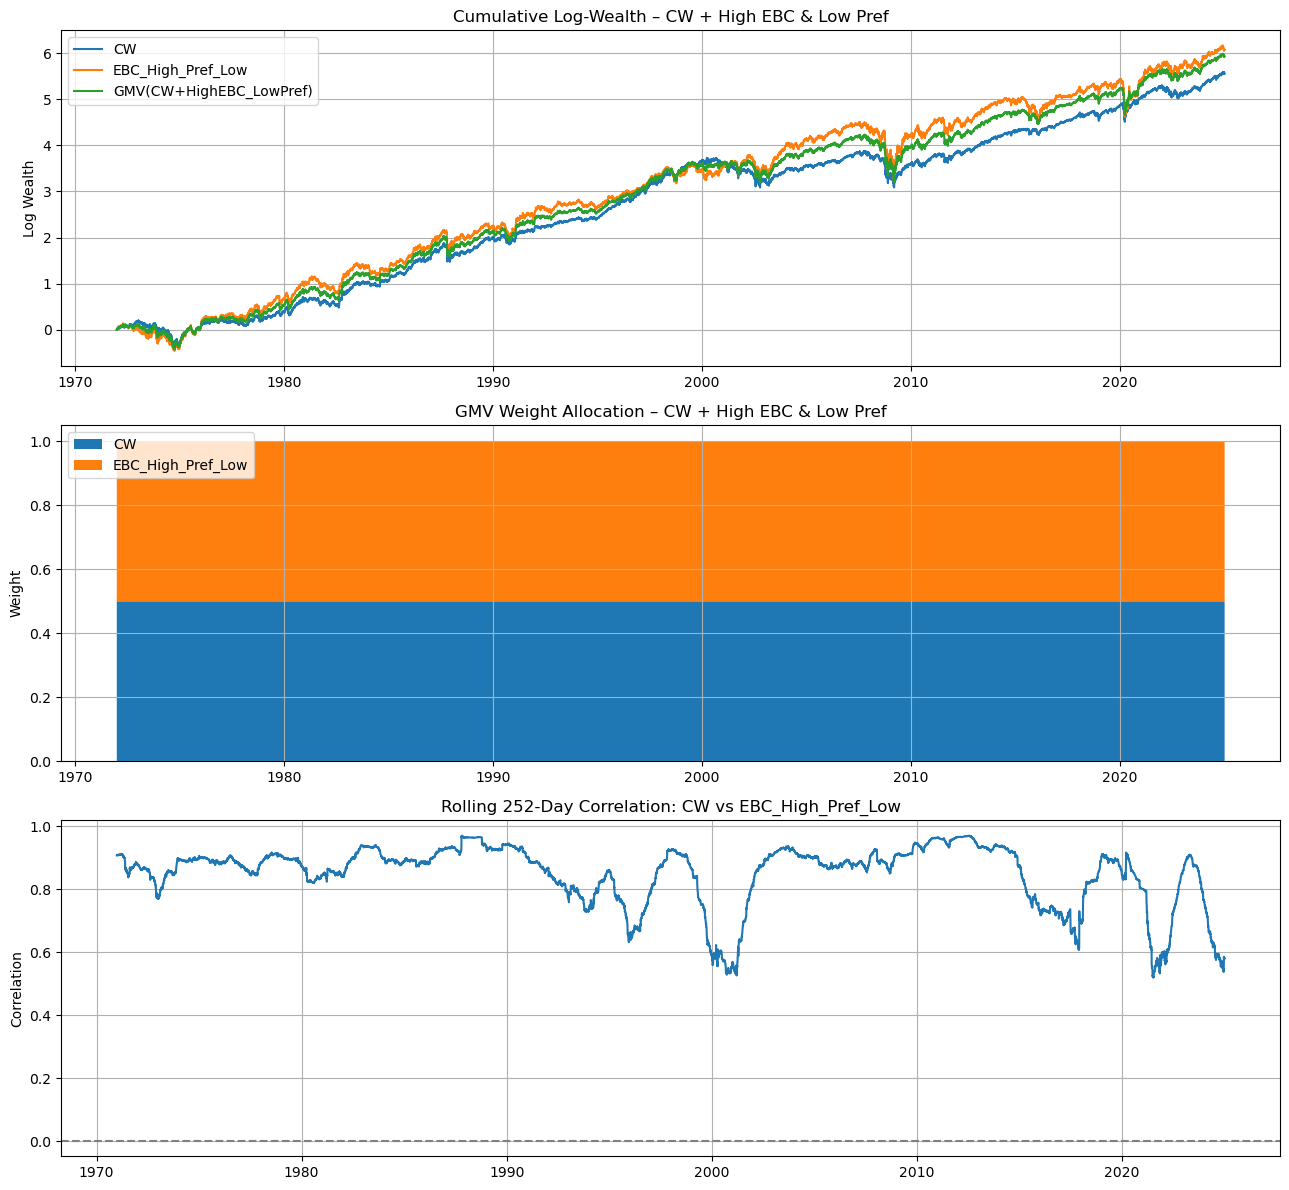

In [9]:
plot_2asset_gmv(
    ret_c2, wts_c2,
    assets_c2["CW"], assets_c2["EBC_High_Pref_Low"],
    "CW", "EBC_High_Pref_Low",
    "CW + High EBC & Low Pref"
)

In [10]:
idx = ret_c2.index
pd.DataFrame({
    'CW':                  summary_stats(assets_c2.loc[idx, 'CW']),
    'EBC_High_Pref_Low':   summary_stats(assets_c2.loc[idx, 'EBC_High_Pref_Low']),
    ret_c2.name:           summary_stats(ret_c2),
}).T.round(4)

,Ann. Return,Ann. Vol,Sharpe,Cum. Return,Max DD (log)
CW,0.1270,0.1723,0.7374,256.9826,-0.7928
EBC_High_Pref_Low,0.1544,0.2413,0.6398,430.0899,-1.2976
GMV(CW+HighEBC_LowPref),0.1406,0.1987,0.7076,374.1837,-1.0247


---
## Case 3: CW + Mid EBC & Low Pref

In [11]:
assets_c3 = df_3x3[["CW", "EBC_Mid_Pref_Low"]].dropna()

ret_c3, wts_c3 = run_gmv_backtest(
    assets_c3, rebalance_freq=REBAL, lookback=LOOKBACK,
    use_full_history=FULL_HIST, min_obs=MIN_OBS
)
ret_c3.name = "GMV(CW+MidEBC_LowPref)"

print(f"Backtest: {ret_c3.index.min().date()} to {ret_c3.index.max().date()}  ({len(ret_c3)} days)")
wts_c3.tail()

Backtest: 1971-12-28 to 2024-12-31  (13368 days)


,CW,EBC_Mid_Pref_Low
date,,
2024-12-24,0.5,0.5
2024-12-26,0.5,0.5
2024-12-27,0.5,0.5
2024-12-30,0.5,0.5
2024-12-31,0.5,0.5


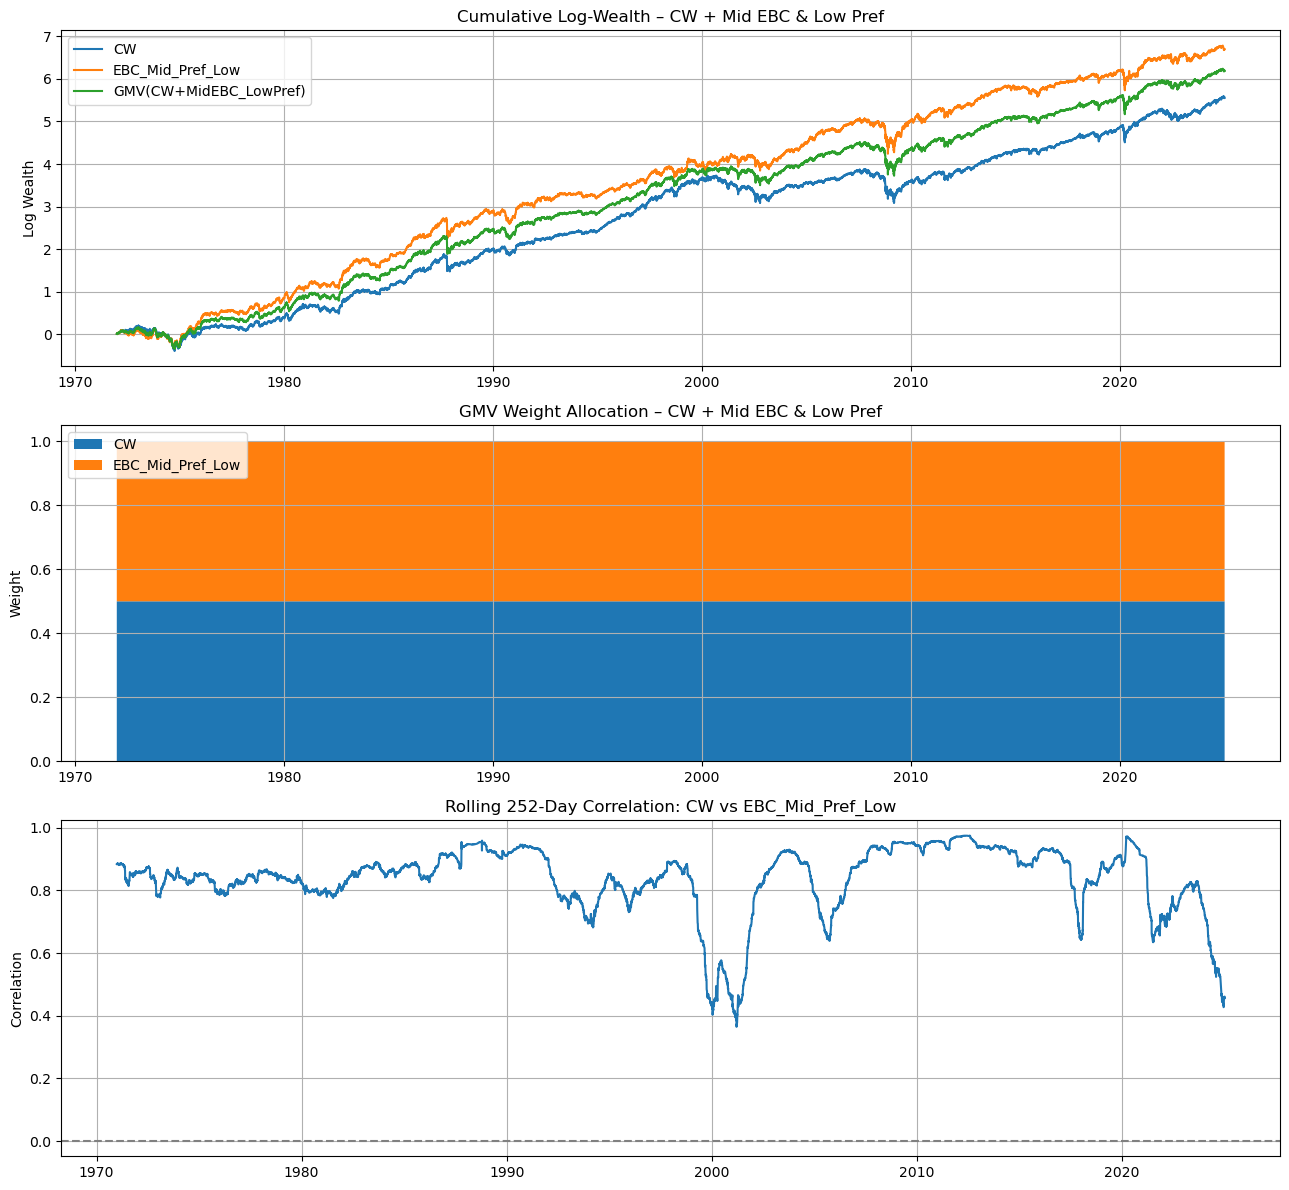

In [12]:
plot_2asset_gmv(
    ret_c3, wts_c3,
    assets_c3["CW"], assets_c3["EBC_Mid_Pref_Low"],
    "CW", "EBC_Mid_Pref_Low",
    "CW + Mid EBC & Low Pref"
)

In [13]:
idx = ret_c3.index
pd.DataFrame({
    'CW':                 summary_stats(assets_c3.loc[idx, 'CW']),
    'EBC_Mid_Pref_Low':   summary_stats(assets_c3.loc[idx, 'EBC_Mid_Pref_Low']),
    ret_c3.name:          summary_stats(ret_c3),
}).T.round(4)

,Ann. Return,Ann. Vol,Sharpe,Cum. Return,Max DD (log)
CW,0.1270,0.1723,0.7374,256.9826,-0.7928
EBC_Mid_Pref_Low,0.1533,0.1812,0.8461,805.4816,-0.8315
GMV(CW+MidEBC_LowPref),0.1401,0.1702,0.8233,483.7261,-0.7914


---
## Comparison: All Three GMV Strategies vs CW

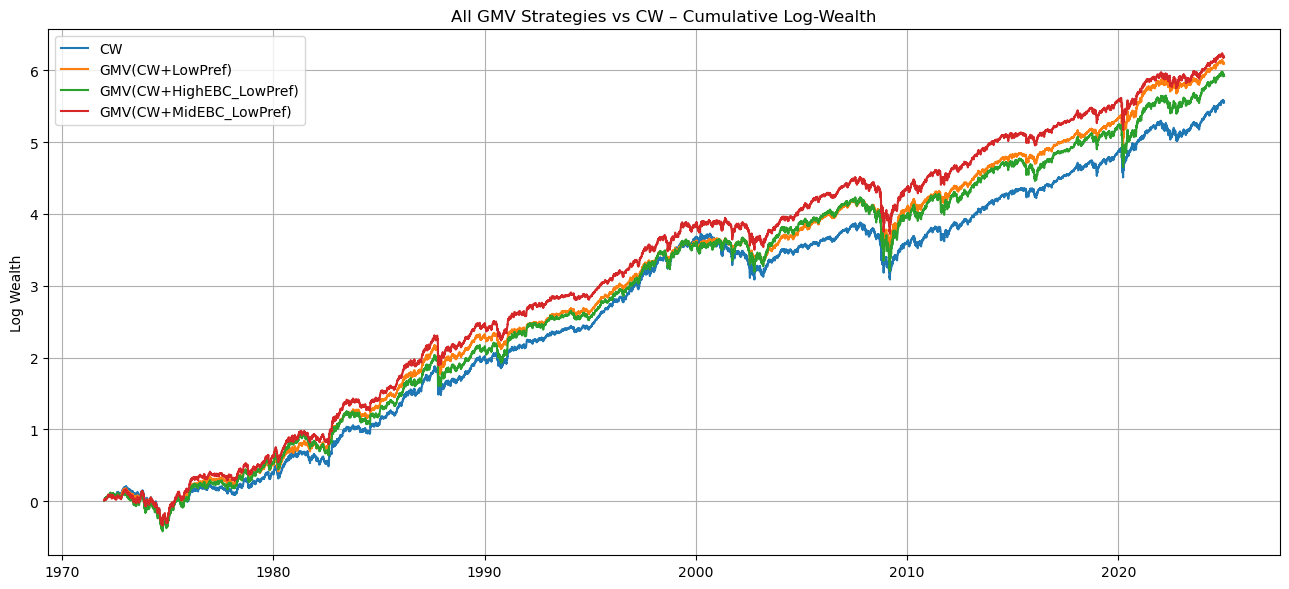

,Ann. Return,Ann. Vol,Sharpe,Cum. Return,Max DD (log)
CW,0.1270,0.1723,0.7374,256.9826,-0.7928
GMV(CW+LowPref),0.1365,0.1610,0.8475,442.9735,-0.7927
GMV(CW+HighEBC_LowPref),0.1406,0.1987,0.7076,374.1837,-1.0247
GMV(CW+MidEBC_LowPref),0.1401,0.1702,0.8233,483.7261,-0.7914


In [14]:
common_idx = ret_c1.index.intersection(ret_c2.index).intersection(ret_c3.index)
cw_common  = df_1x3.loc[common_idx, 'CW']

series = {
    'CW':          cw_common,
    ret_c1.name:   ret_c1.loc[common_idx],
    ret_c2.name:   ret_c2.loc[common_idx],
    ret_c3.name:   ret_c3.loc[common_idx],
}

fig, ax = plt.subplots(figsize=(13, 6))
for name, s in series.items():
    ax.plot(np.log1p(s).cumsum(), label=name)
ax.set_title("All GMV Strategies vs CW – Cumulative Log-Wealth")
ax.set_ylabel("Log Wealth"); ax.legend(); ax.grid(True)
plt.tight_layout()
plt.show()

pd.DataFrame({k: summary_stats(v) for k, v in series.items()}).T.round(4)